# Restuarant Tips
Running a successful restaurant requires a balance of quality food, efficient operations, attentive staff, and strategic marketing.

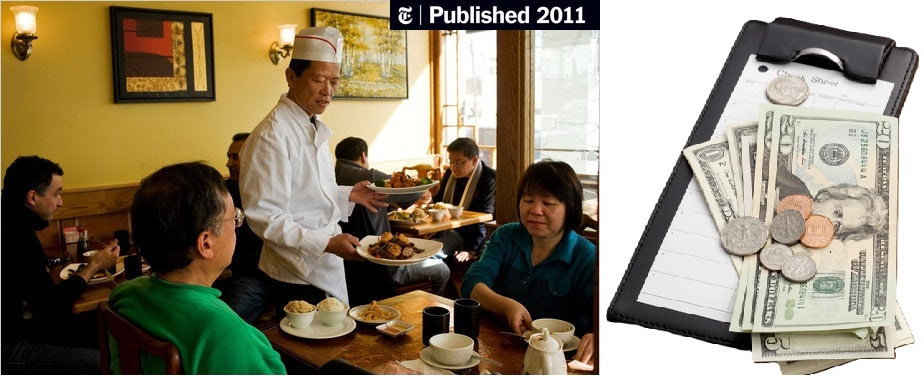

In [1]:
from IPython.display import Image
Image(filename='image.jpg', width=700)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Import dataset
df = pd.read_csv('tips.csv')

In [4]:
# get the head of dataset
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
# info of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [6]:
# Summary statistic of the dataset
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


* Tips has value range from 1-10
* Table size has maximum value of 6

### Data Cleaning

In [7]:
# Check for missing value
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

* No Missing values in the dataset.

### Exploratory Data Analysis (EDA)
* 1. Total Bill

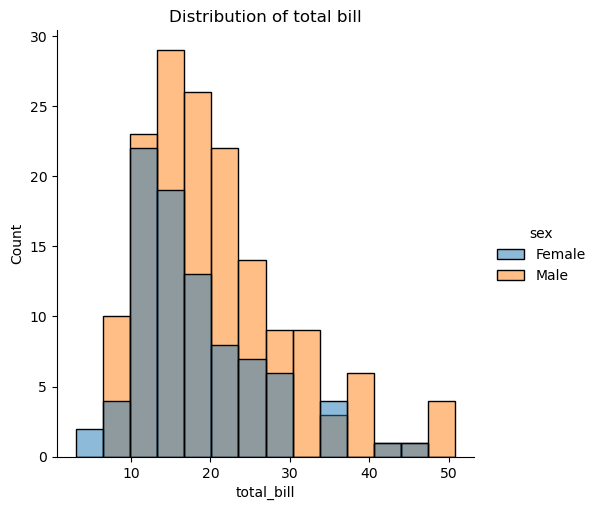

In [8]:
# distribution of total bill
sns.displot(x='total_bill', data=df, hue='sex')
plt.title('Distribution of total bill');

* The total bill is right skewed with max total bill between 10 and 20.

* **2. Tip**

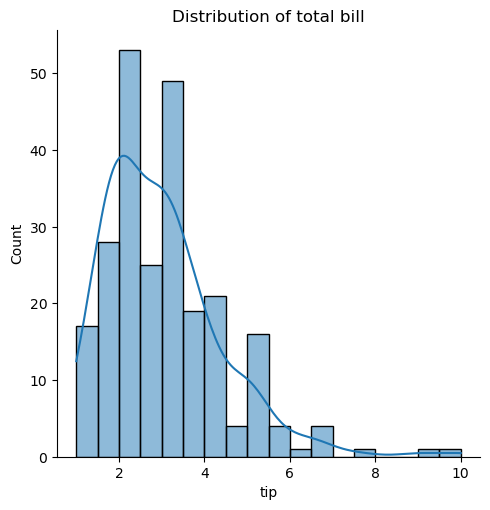

In [9]:
# distribution of total bill
ax = sns.displot(x='tip', data=df, kde=True)
plt.title('Distribution of total bill');

* The tip variable is right skewed with max value around 2.

**3. Sex**

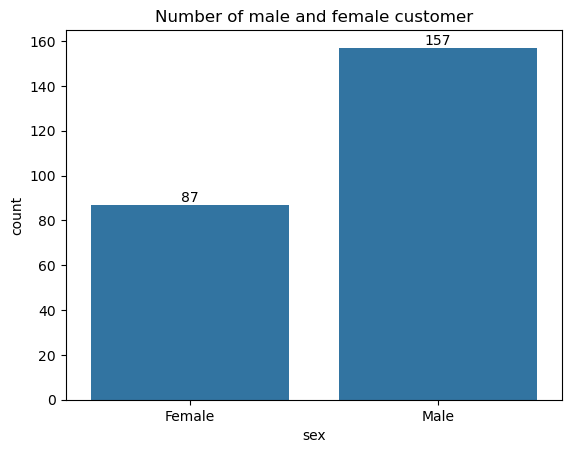

In [10]:
# Countplot of sex
ax = sns.countplot(x='sex', data=df)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Number of male and female customer');

* The Restaurant has more male than female.

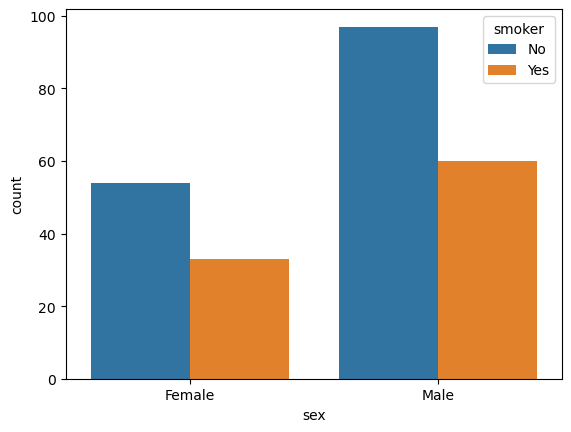

In [11]:
# Countplot of smoker by sex
sns.countplot(x='sex', data=df, hue='smoker');

* There are more non-smoker count in both male and female.
* There are les smoker count in both male and female.

**4. Smoker**

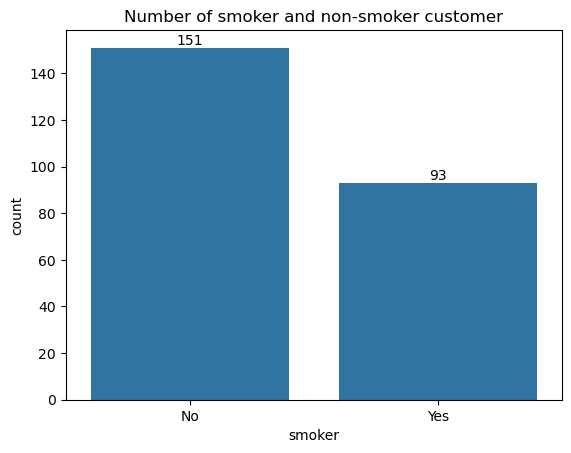

In [12]:
# Countplot of smoker
ax = sns.countplot(x='smoker', data=df)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Number of smoker and non-smoker customer');

* The restuarant has more non-smoker customer than smoker customer.

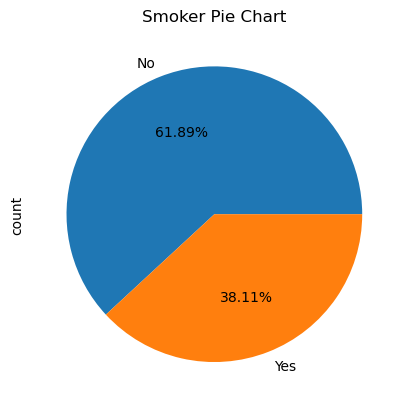

In [13]:
df['smoker'].value_counts().plot(kind='pie', autopct='%.2f%%')
plt.title("Smoker Pie Chart");

**5. Day**

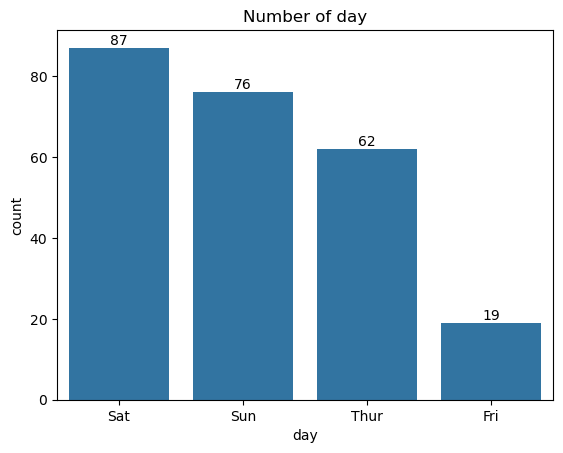

In [14]:
# Countplot of day
day_order = ['Sat', 'Sun', 'Thur', 'Fri']
ax = sns.countplot(x='day', data=df, order=day_order)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Number of day');

* Day in the data consists of weekend (Saturday and Sunday) which has more customer.
* Weekday (Thursday and Friday) which has less customer count.

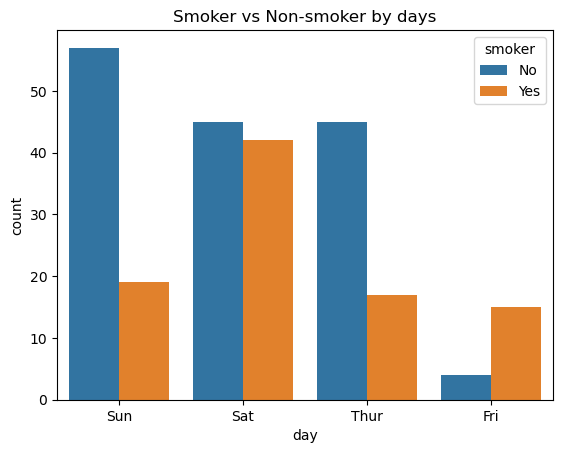

In [15]:
# Countplot of smoker by day
sns.countplot(x='day', data=df, hue='smoker')
plt.title('Smoker vs Non-smoker by days');

Only on friday there are more smoker than non-smoker.

**6. Time**

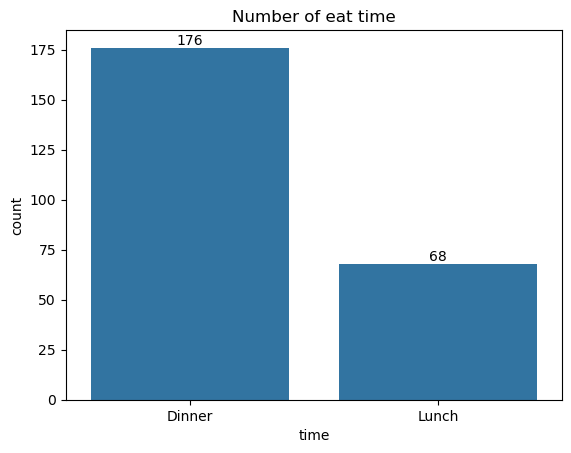

In [16]:
# Countplot of eat time
ax = sns.countplot(x='time', data=df)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Number of eat time');

* Dinner has the most count.

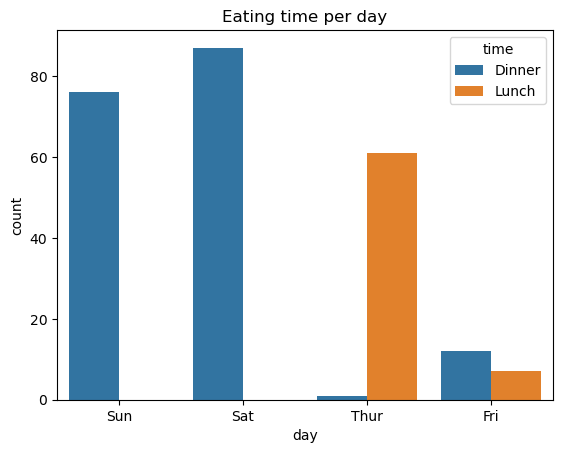

In [17]:
# Countplot of eating time by day
sns.countplot(x='day', data=df, hue='time')
plt.title('Eating time per day');

* Customer buy dinner only on weekends (Sunday & Saturday).
* On thursday customer buy lunch more.
* On friday the proportion time sales is 60:40.

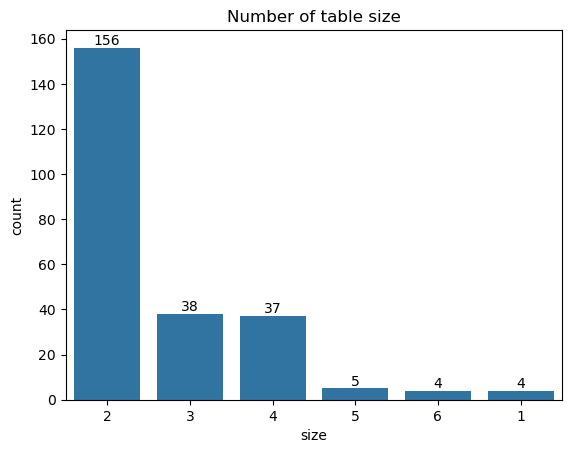

In [18]:
size = [2,3,4,5,6,1]
ax = sns.countplot(x='size', data=df, order=size)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Number of table size');

* Table with size two (2) has the most count.

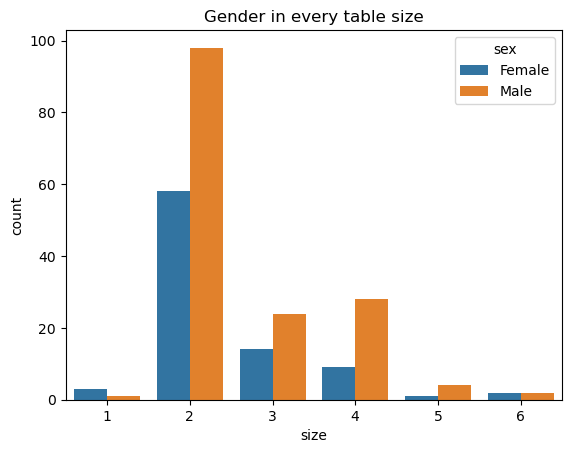

In [19]:
# Count plot of gender by size
sns.countplot(x='size', data=df, hue='sex')
plt.title('Gender in every table size');

* Female customer are more than male in table size 1 while.
* Male customer are more in other table sizes.

## Relationship between variables

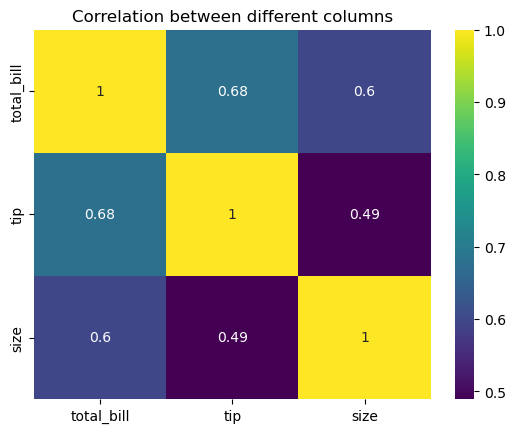

In [20]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='viridis')
plt.title('Correlation between different columns');

* Total bill and tip has a strong correlation at 0.68.
* Total bill and size has a strong correlation at 0.6.
* Tip and size has a moderate correlation at 0.49.

### Scatter Plot.

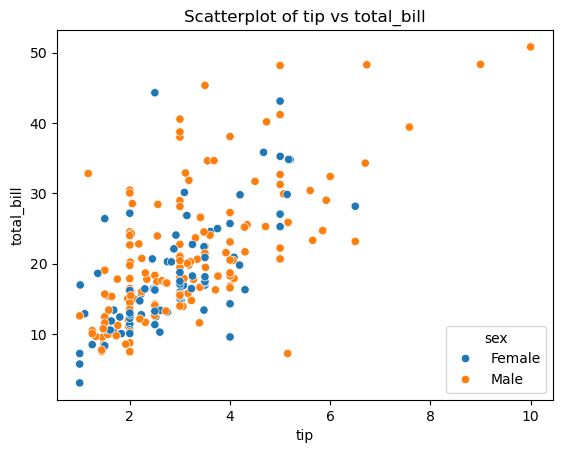

In [21]:
sns.scatterplot(x='tip', y='total_bill', data=df, hue='sex')
plt.title('Scatterplot of tip vs total_bill');

* There is a linear reletionship between total bill and tip.

In [22]:
# Bar plot of sum tip per size
sztp = df.groupby('size')['tip'].sum().reset_index(name='total_tip')
sztp

,size,total_tip
0,1,5.75
1,2,402.84
2,3,128.94
3,4,153.01
4,5,20.14
5,6,20.90


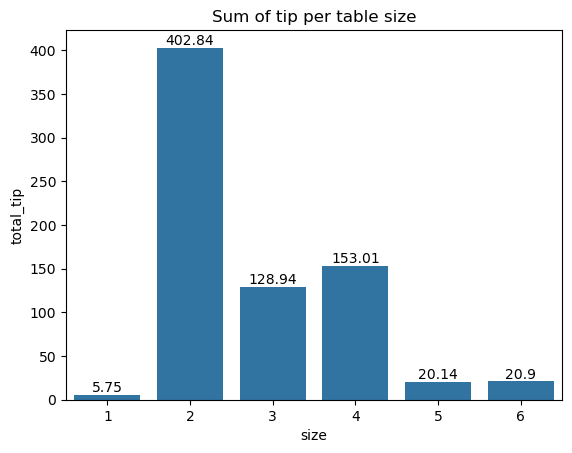

In [23]:
ax = sns.barplot(x='size', y='total_tip', data=sztp)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Sum of tip per table size');

* Table with size 2 has the highest total tip with huge different than other.

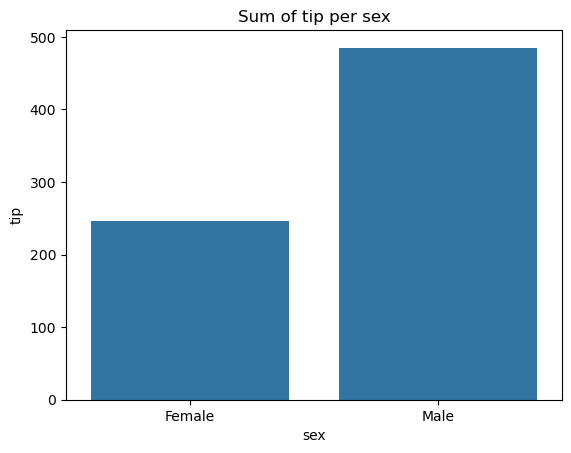

In [24]:
sextp = df.groupby('sex')['tip'].sum().reset_index()
sns.barplot(x='sex', y='tip', data=sextp)
plt.title('Sum of tip per sex');

* Male has more tips than female.

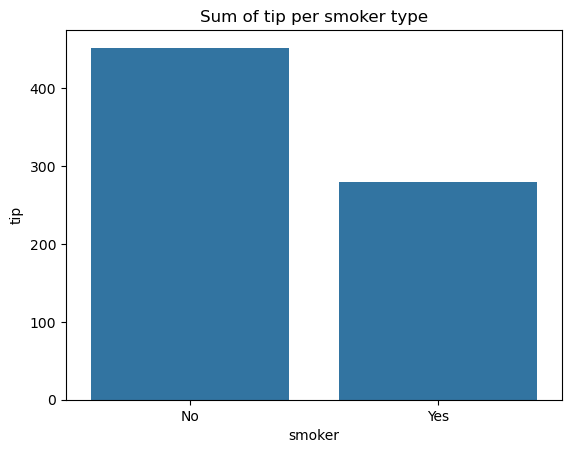

In [25]:
smoktp = df.groupby('smoker')['tip'].sum().reset_index()
sns.barplot(x='smoker', y='tip', data=smoktp)
plt.title('Sum of tip per smoker type');

* Non Smoker has bigger tip than smoker.

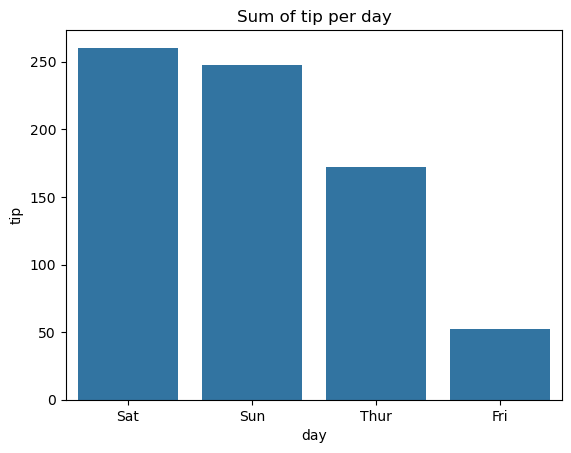

In [26]:
daytp = df.groupby('day')['tip'].sum().reset_index()
order = ['Sat','Sun','Thur','Fri']
sns.barplot(x='day', y='tip', data=daytp, order=order)
plt.title('Sum of tip per day');

* Weekend (Saturday & Sunday) has bigger tip than weekdays (Thursday & Friday).

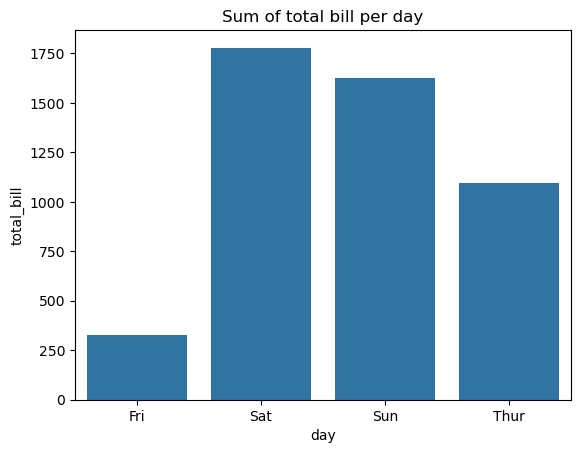

In [27]:
# Barplot of sum total bill by day
time_bill = df.groupby('day')['total_bill'].sum().reset_index()
sns.barplot(x='day',y='total_bill',data=time_bill)
plt.title('Sum of total bill per day');

* More bill on weekend than on weekdays.

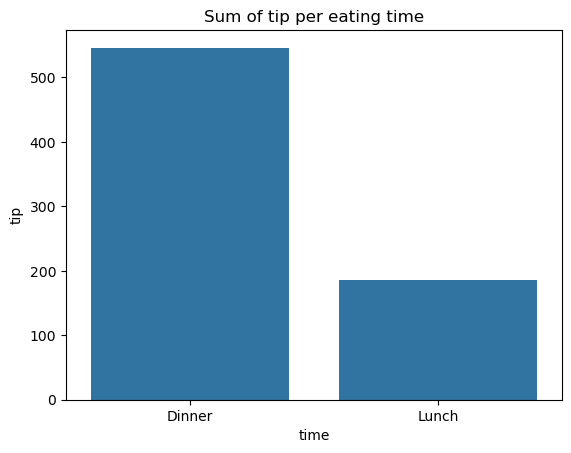

In [28]:
timtp = df.groupby('time')['tip'].sum().reset_index()
sns.barplot(x='time',y='tip',data=timtp)
plt.title('Sum of tip per eating time');

* Tip of dinner is almost 3 times higher than lunch time.

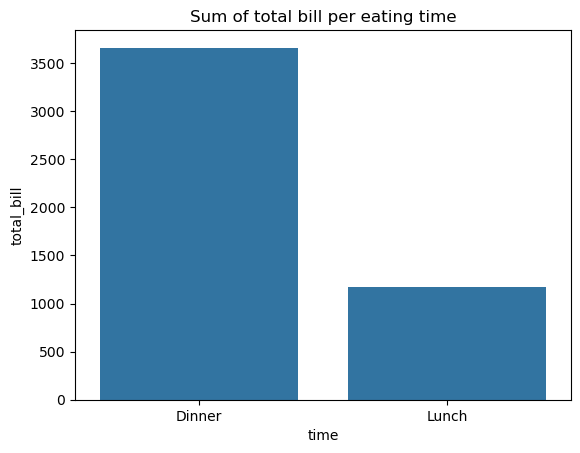

In [29]:
# Barplot of sum total bill by time
time_bill = df.groupby('time')['total_bill'].sum().reset_index()
sns.barplot(x='time',y='total_bill',data=time_bill)
plt.title('Sum of total bill per eating time');

* More bill on dinner than on lunch time.

# Great Job!!